# 🇨🇱 Chile - Consumer Food Prices Analysis (ODEPA 2026)

Analysis of consumer food prices from Chile's [ODEPA](https://www.odepa.gob.cl/) (Oficina de Estudios y Políticas Agrarias).

**Data source:** `precio_consumidor_publico_2026.csv`  
**Period:** January – March 2026  
**Scope:** 9 regions, ~230 products across fruits, vegetables, dairy, meats, and staples.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
})


## 1. Loading & Cleaning

In [2]:
# Load CSV — Chilean format uses comma as decimal separator
df = pd.read_csv("precio_consumidor_publico_2026.csv", encoding="utf-8-sig")

# Clean price columns
for col in ["Precio minimo", "Precio maximo", "Precio promedio"]:
    df[col] = df[col].astype(str).str.replace(",", ".").astype(float)

# Parse dates
df["Fecha inicio"] = pd.to_datetime(df["Fecha inicio"])
df["Fecha termino"] = pd.to_datetime(df["Fecha termino"])

# Extract base product name (before the pipe)
df["producto_base"] = df["Producto"].str.split("|").str[0].str.strip()

# Short region names
df["region_short"] = df["Region"].str.replace("Región de ", "").str.replace("Región del ", "").str.replace("Región Metropolitana de Santiago", "RM Santiago")

print(f"Rows: {len(df):,}")
print(f"Period: {df['Fecha inicio'].min().date()} → {df['Fecha termino'].max().date()}")
print(f"Regions: {df['Region'].nunique()}")
print(f"Products: {df['Producto'].nunique()}")
print(f"Groups: {df['Grupo'].nunique()}")
df.head(3)


Rows: 71,698
Period: 2025-12-29 → 2026-03-20
Regions: 9
Products: 232
Groups: 7


,Anio,Mes,Semana,Fecha inicio,Fecha termino,ID region,Region,Sector,Tipo de punto monitoreo,Grupo,Producto,Unidad,Precio minimo,Precio maximo,Precio promedio,producto_base,region_short
0,2026,1,5,2026-01-26,2026-01-30,9,Región de La Araucanía,Alemania - Pedro de Valdivia,Supermercado,Lácteos - Huevos - Margarinas,Yoghurt,$/bolsa 1 kilo,1690.0,2190.0,1871.176470,Yoghurt,La Araucanía
1,2026,1,1,2025-12-29,2026-01-02,13,Región Metropolitana de Santiago,Poniente,Supermercado,Lácteos - Huevos - Margarinas,Leche en Polvo Descremada,$/bolsa 800 grs,5790.0,7490.0,6854.285714,Leche en Polvo Descremada,RM Santiago
2,2026,2,8,2026-02-16,2026-02-20,15,Región de Arica y Parinacota,Arica,Carnicería,Carne de Cerdo - Ave - Cordero,Pavo Pechuga s/hueso,$/kilo,6999.0,7490.0,7244.500000,Pavo Pechuga s/hueso,Arica y Parinacota


## 2. Data Overview

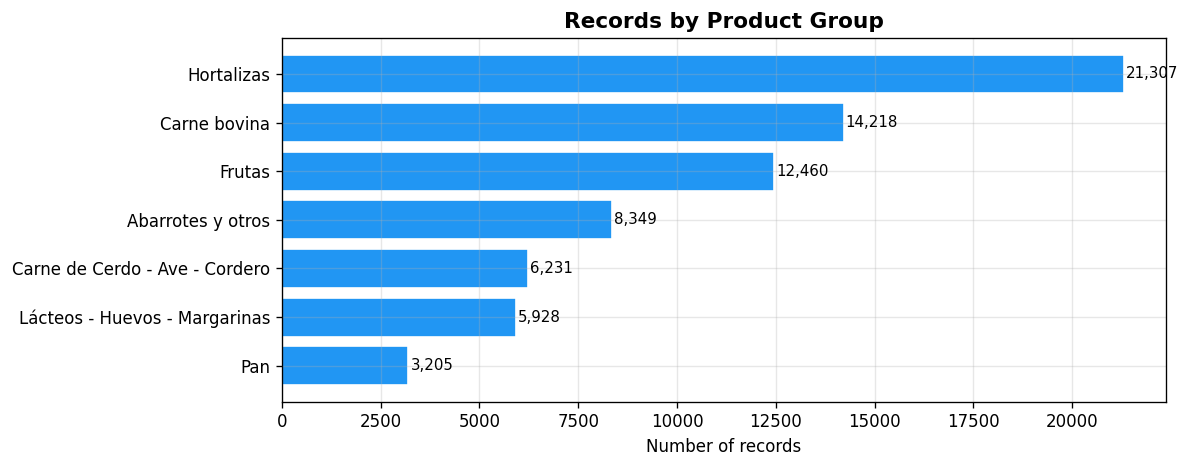

In [3]:
# Records per product group
group_counts = df.groupby("Grupo").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(group_counts.index, group_counts.values, color="#2196F3", edgecolor="white")
ax.set_xlabel("Number of records")
ax.set_title("Records by Product Group")
for bar, val in zip(bars, group_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


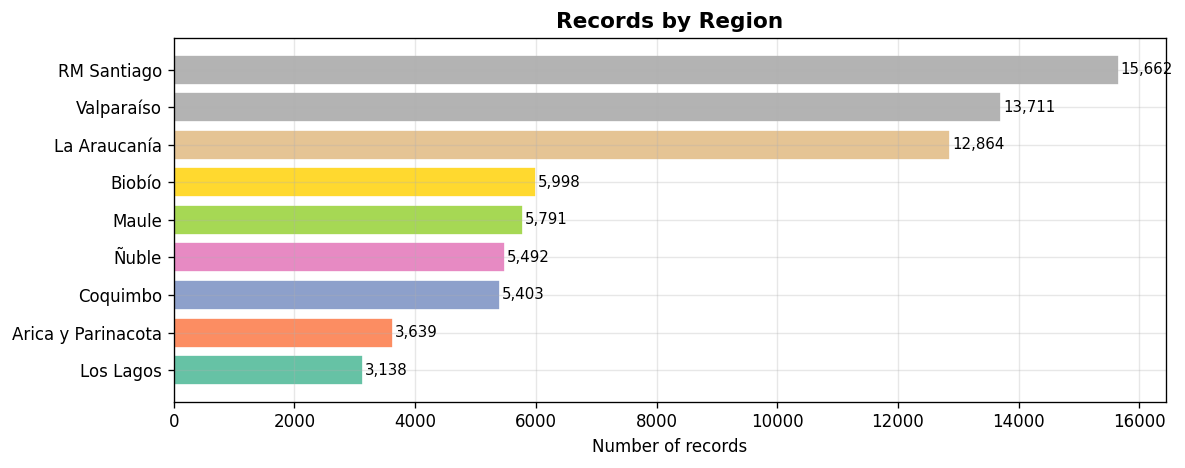

In [4]:
# Records per region
region_counts = df.groupby("region_short").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(region_counts)))
bars = ax.barh(region_counts.index, region_counts.values, color=colors, edgecolor="white")
ax.set_xlabel("Number of records")
ax.set_title("Records by Region")
for bar, val in zip(bars, region_counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 3. Weekly Price Trends — Key Products

Tracking average weekly prices across all regions for staple fruits and vegetables.


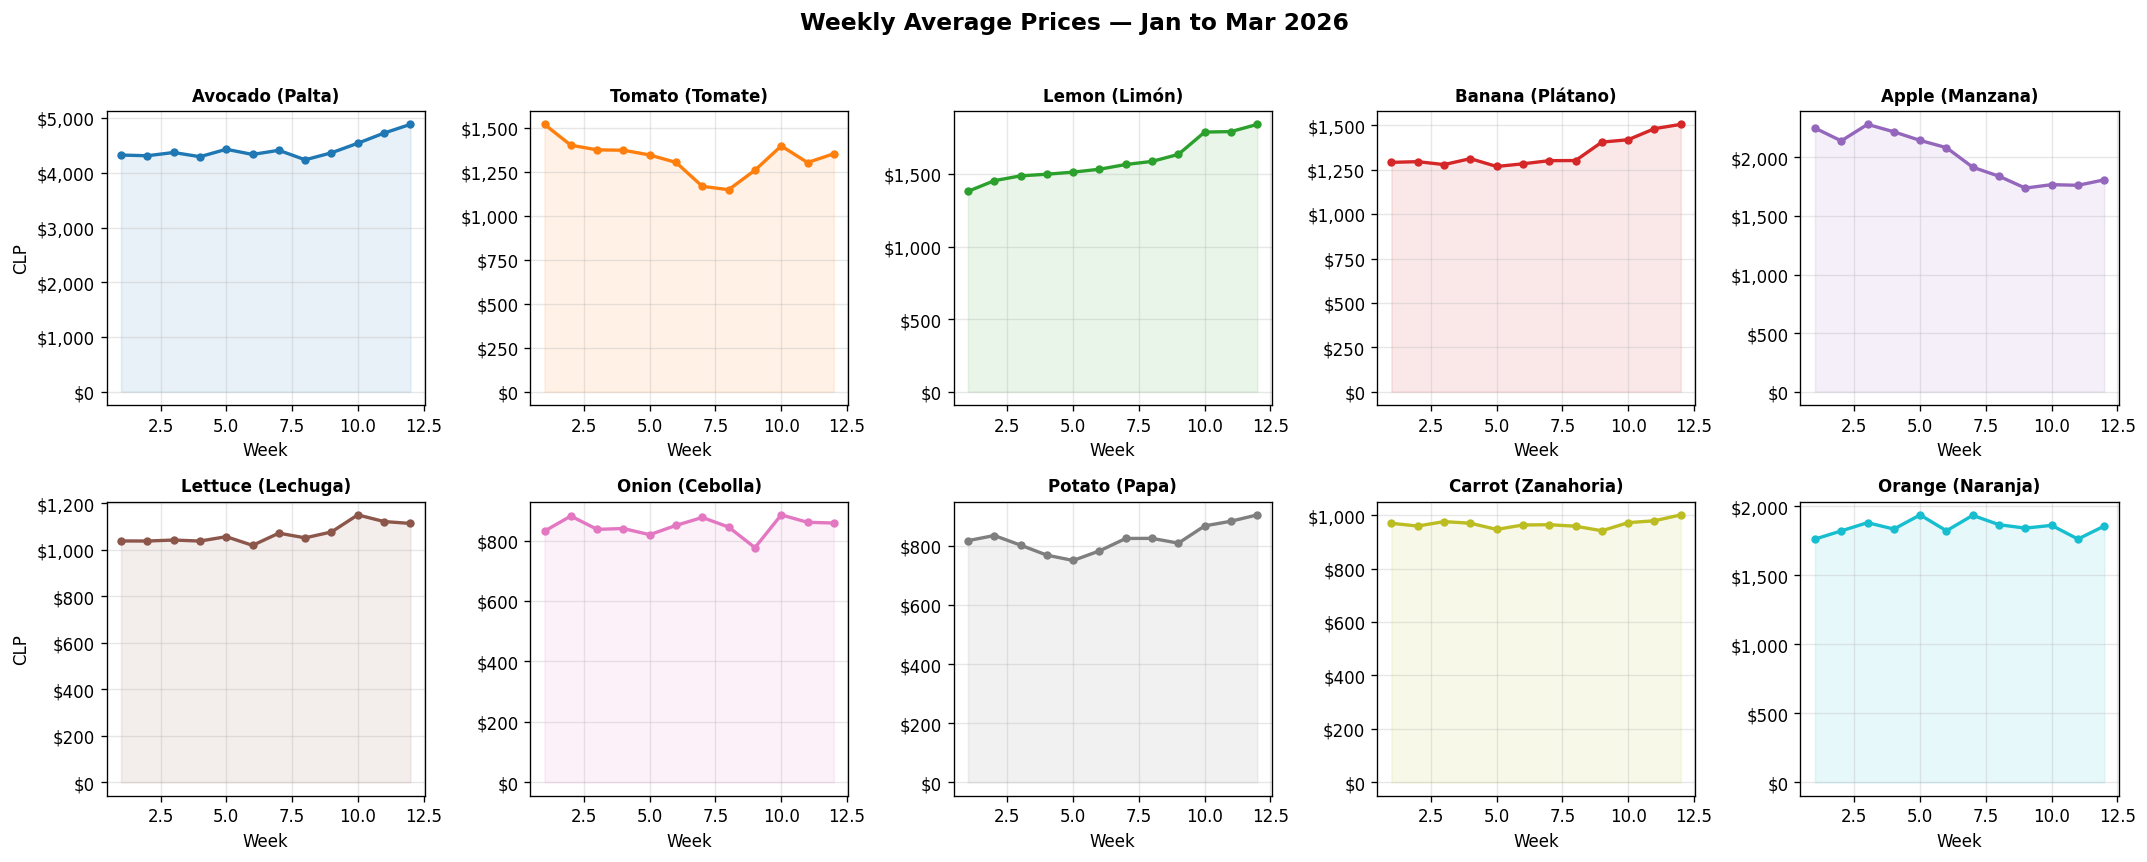

In [5]:
# Define products of interest with friendly names
PRODUCTS_MAP = {
    "Palta": "Avocado (Palta)",
    "Tomate": "Tomato (Tomate)",
    "Limón": "Lemon (Limón)",
    "Plátano": "Banana (Plátano)",
    "Manzana": "Apple (Manzana)",
    "Lechuga": "Lettuce (Lechuga)",
    "Cebolla": "Onion (Cebolla)",
    "Papa": "Potato (Papa)",
    "Zanahoria": "Carrot (Zanahoria)",
    "Naranja": "Orange (Naranja)",
}

# Filter and compute weekly average
df_key = df[df["producto_base"].isin(PRODUCTS_MAP.keys())].copy()
df_key["week"] = df_key["Fecha inicio"].dt.isocalendar().week.astype(int)
df_key["friendly"] = df_key["producto_base"].map(PRODUCTS_MAP)

weekly = df_key.groupby(["week", "friendly"])["Precio promedio"].mean().reset_index()

# Plot grid
products_list = list(PRODUCTS_MAP.values())
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

palette = plt.cm.tab10(np.linspace(0, 1, 10))

for i, prod in enumerate(products_list):
    ax = axes[i]
    data = weekly[weekly["friendly"] == prod].sort_values("week")
    ax.plot(data["week"], data["Precio promedio"], marker="o", markersize=4,
            color=palette[i], linewidth=2)
    ax.fill_between(data["week"], data["Precio promedio"], alpha=0.1, color=palette[i])
    ax.set_title(prod, fontsize=10)
    ax.set_xlabel("Week")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    if i % 5 == 0:
        ax.set_ylabel("CLP")

fig.suptitle("Weekly Average Prices — Jan to Mar 2026", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 4. Regional Price Comparison

How do average prices differ across Chile's regions? Focusing on avocado (Palta Hass) and tomato.


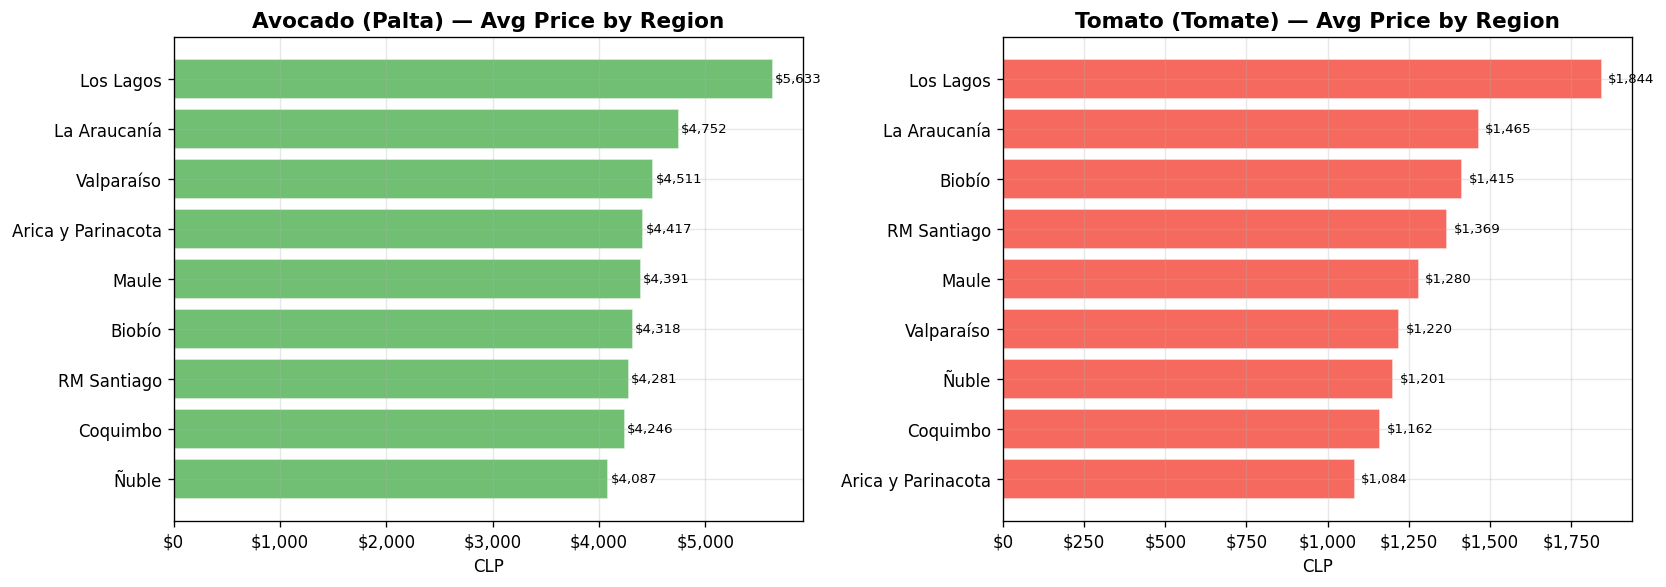

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prod, color in zip(axes, ["Palta", "Tomate"], ["#4CAF50", "#F44336"]):
    data = df[df["producto_base"] == prod].copy()
    region_avg = data.groupby("region_short")["Precio promedio"].mean().sort_values()
    
    bars = ax.barh(region_avg.index, region_avg.values, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{PRODUCTS_MAP.get(prod, prod)} — Avg Price by Region")
    ax.set_xlabel("CLP")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    
    for bar, val in zip(bars, region_avg.values):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2, f"${val:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 5. Price Volatility (Spread)

The gap between minimum and maximum prices reveals how much prices vary within each week. 
A large spread may indicate regional disparities or supply instability.


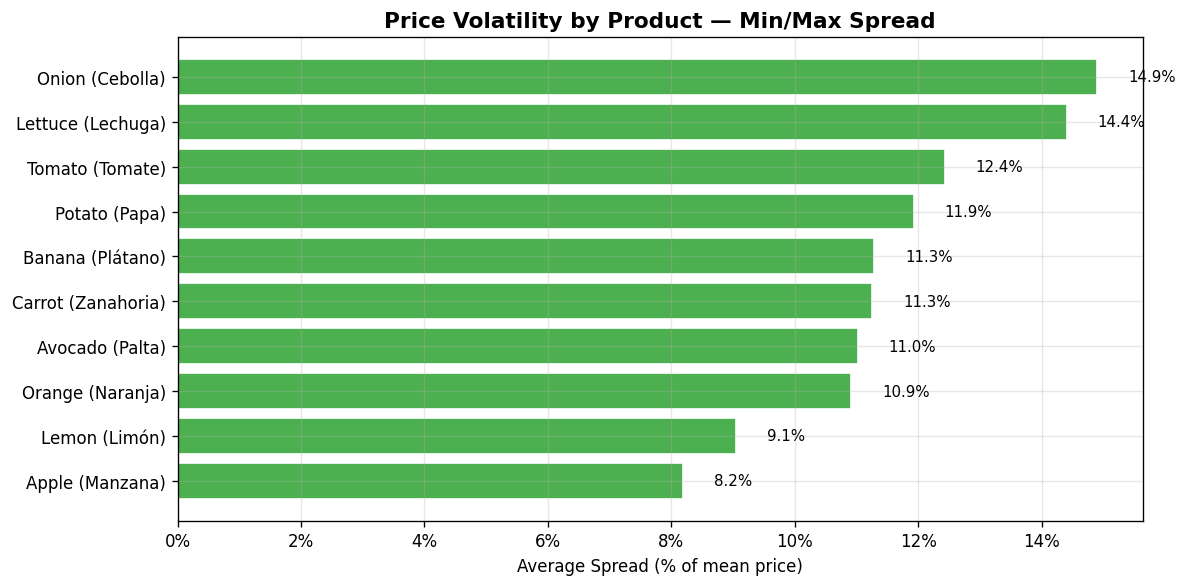

In [7]:
df_key["spread"] = df_key["Precio maximo"] - df_key["Precio minimo"]
df_key["spread_pct"] = (df_key["spread"] / df_key["Precio promedio"]) * 100

vol = df_key.groupby("friendly")["spread_pct"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F44336" if v > 40 else "#FF9800" if v > 25 else "#4CAF50" for v in vol.values]
bars = ax.barh(vol.index, vol.values, color=colors, edgecolor="white")
ax.set_xlabel("Average Spread (% of mean price)")
ax.set_title("Price Volatility by Product — Min/Max Spread")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for bar, val in zip(bars, vol.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 6. Price Heatmap — Region × Product

Average prices for key products across all regions (CLP).


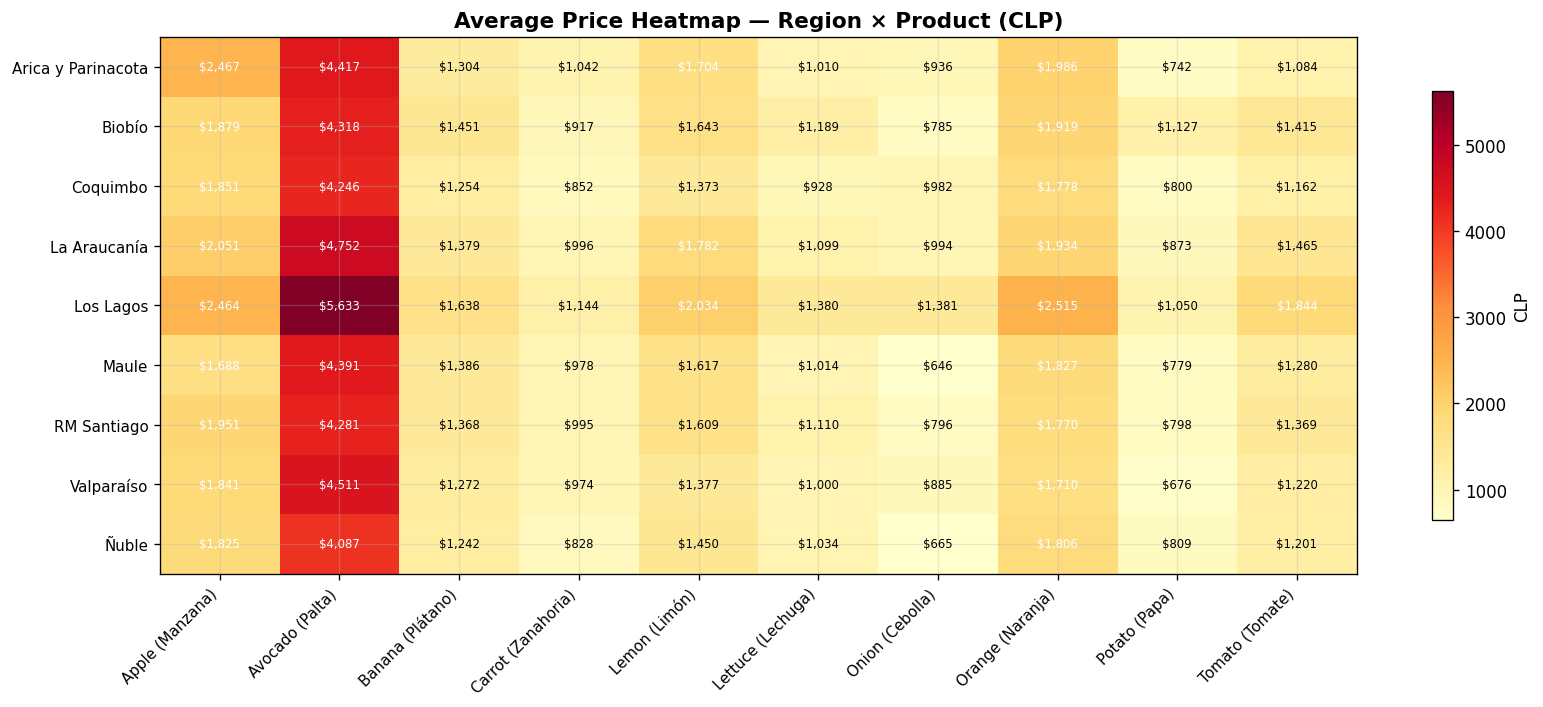

In [8]:
pivot = df_key.groupby(["region_short", "friendly"])["Precio promedio"].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = "white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black"
            ax.text(j, i, f"${val:,.0f}", ha="center", va="center", fontsize=7, color=color)

ax.set_title("Average Price Heatmap — Region × Product (CLP)")
plt.colorbar(im, ax=ax, label="CLP", shrink=0.8)
plt.tight_layout()
plt.show()


## 7. Summary Statistics

In [9]:
summary = df_key.groupby("friendly").agg(
    avg_price=("Precio promedio", "mean"),
    min_price=("Precio minimo", "min"),
    max_price=("Precio maximo", "max"),
    records=("Precio promedio", "count"),
    regions=("Region", "nunique"),
).sort_values("avg_price", ascending=False)

summary["avg_price"] = summary["avg_price"].apply(lambda x: f"${x:,.0f}")
summary["min_price"] = summary["min_price"].apply(lambda x: f"${x:,.0f}")
summary["max_price"] = summary["max_price"].apply(lambda x: f"${x:,.0f}")

summary.columns = ["Avg Price", "Min Price", "Max Price", "Records", "Regions"]
summary


,Avg Price,Min Price,Max Price,Records,Regions
friendly,,,,,
Avocado (Palta),"$4,438","$1,190","$7,000",1153,9
Apple (Manzana),"$1,956",$700,"$3,500",1528,9
Orange (Naranja),"$1,849",$600,"$3,790",1084,9
Lemon (Limón),"$1,593",$5,"$2,990",1689,9
Banana (Plátano),"$1,347",$350,"$7,590",902,9
Tomato (Tomate),"$1,317",$250,"$2,490",1184,9
Lettuce (Lechuga),"$1,069",$250,"$2,000",1788,9
Carrot (Zanahoria),$968,$300,"$1,600",949,9
Onion (Cebolla),$848,$10,"$2,290",1370,9
